# Energy-gap law para los $k_{NR}$ del `ErIon`, extrapolados a $T = 0$ K

1. Tomo los $k_{NR}(T_0)$ de cada `TemperatureDependentInternalRelaxationRef` del modelo y los llevo a $T=0$ (emisión espontánea de fonones, $n=0$):
$$k_{NR}(0) = \frac{k_{NR}(T_0)}{\left[1 + n(T_0)\right]^{p}}$$
2. Ajusto $k_{NR}(0) = B\, e^{-a \Delta E}$ (lineal en $\ln k$).
3. Heatmap de $e^{-a\Delta E}\cdot F(T)$ para todo par de niveles, con el factor de temperatura absoluto (convención de las clases no-`Ref` de `transitions.py`):

$$
F_{\downarrow}(T) = \left[1 + n(T)\right]^{p}, \qquad
F_{\uparrow}(T) = n(T)^{p}, \qquad
n(T) = \frac{1}{e^{\hbar\omega/k_BT} - 1}, \quad p = \frac{\Delta E}{\hbar\omega}
$$

**Ojo:** con $p$ continuo, $[1+n(T_0)]^{p} = e^{\Delta E \ln(1+n(T_0))/\hbar\omega}$ es exponencial en $\Delta E$, así que pasar a 0 K solo corre $a \to a + \ln(1+n(T_0))/\hbar\omega$ (mismo $B$, mismos residuos) y el heatmap queda **idéntico** al de `knr_energy_gap.ipynb`.
Con `CEIL_P = True` ($p$ entero) deja de ser exactamente equivalente.

In [1]:
from upconversion_models.ions.erbium import ErIon
from upconversion_models.transitions import TemperatureDependentInternalRelaxationRef
from upconversion_models.utils import h, c, k, hc
from jablonski import SingletState
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import pint

u = pint.get_application_registry()
er = ErIon()

## 1. $k_{NR}$ del modelo vs $\Delta E$

In [2]:
names, gaps, knr = [], [], []
for t in er._yield(TemperatureDependentInternalRelaxationRef):
    names.append(f"{t.source}→{t.target}")
    gaps.append(t._gap_wavenumber.default.to(1 / u.cm).magnitude)
    knr.append(t.reference_rate.default.to(1 / u.s).magnitude)

names, gaps, knr = np.array(names), np.array(gaps), np.array(knr)
phonon_wavenumber = next(er._yield(TemperatureDependentInternalRelaxationRef)).phonon_wavenumber.default.to(1 / u.cm).magnitude
T0 = ErIon.T0.default.to(u.K).magnitude

CEIL_P = False  # True: p = ceil(ΔE / ħω), como en temperature_dependance.ipynb
kB = (k / hc).to(1 / (u.cm * u.K)).magnitude  # cm⁻¹ / K


def occupation(T):
    return 1 / np.expm1(phonon_wavenumber / (kB * T))


def phonon_number(dE):
    p = dE / phonon_wavenumber
    return np.ceil(p) if CEIL_P else p


knr_T0 = knr
knr = knr_T0 / (1 + occupation(T0)) ** phonon_number(gaps)  # k_nr(T = 0 K)

for n_, g, k1, kk in zip(names, gaps, knr_T0, knr):
    print(f"{n_:>10}  ΔE = {g:6.0f} cm⁻¹   k_nr(T0) = {k1:9.3g} s⁻¹   k_nr(0 K) = {kk:9.3g} s⁻¹")
print(f"\nħω = {phonon_wavenumber} cm⁻¹, T0 = {T0} K, n(T0) = {occupation(T0):.3f}")

   Er9→Er8  ΔE =   1600 cm⁻¹   k_nr(T0) =  1.76e+06 s⁻¹   k_nr(0 K) =  6.85e+05 s⁻¹
   Er8→Er7  ΔE =   4000 cm⁻¹   k_nr(T0) =  4.34e+04 s⁻¹   k_nr(0 K) =   4.1e+03 s⁻¹
  Er7→Er6h  ΔE =   1300 cm⁻¹   k_nr(T0) =     1e+06 s⁻¹   k_nr(0 K) =  4.64e+05 s⁻¹
  Er6h→Er5  ΔE =   4200 cm⁻¹   k_nr(T0) =        26 s⁻¹   k_nr(0 K) =      2.18 s⁻¹
  Er6s→Er5  ΔE =   3300 cm⁻¹   k_nr(T0) =        26 s⁻¹   k_nr(0 K) =      3.71 s⁻¹
   Er5→Er4  ΔE =   2500 cm⁻¹   k_nr(T0) =         0 s⁻¹   k_nr(0 K) =         0 s⁻¹
   Er4→Er3  ΔE =   2300 cm⁻¹   k_nr(T0) =  2.21e+04 s⁻¹   k_nr(0 K) =  5.69e+03 s⁻¹
   Er3→Er2  ΔE =   3700 cm⁻¹   k_nr(T0) =        61 s⁻¹   k_nr(0 K) =      6.87 s⁻¹

ħω = 350 cm⁻¹, T0 = 300 K, n(T0) = 0.229


## 2. Ajuste exponencial

Ajuste lineal de $\ln k$ vs $\Delta E$. Las transiciones con $k_{NR}=0$ (Er5→Er4) no entran.
`EXCLUDE` permite sacar outliers del ajuste que se usa en el heatmap (p.ej. `{"Er8→Er7"}`); la curva punteada muestra siempre el ajuste con todos los puntos para comparar.

todos:       a = 3.849e-03 cm,  B = 6.557e+07 s⁻¹
sin EXCLUDE: a = 2.455e-03 cm,  B = 3.581e+05 s⁻¹


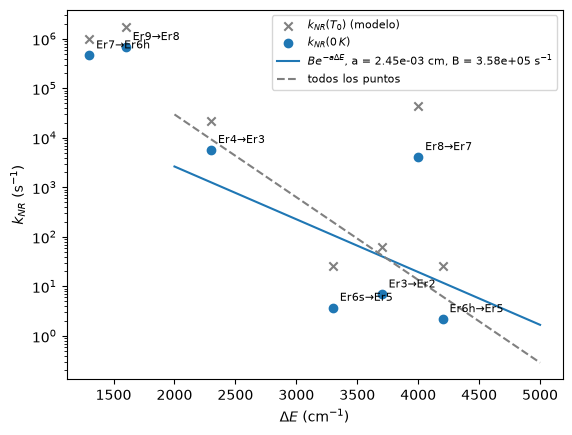

   Er9→Er8  log10(k / fit) = +1.99
   Er8→Er7  log10(k / fit) = +2.32
  Er7→Er6h  log10(k / fit) = +1.50
  Er6h→Er5  log10(k / fit) = -0.74
  Er6s→Er5  log10(k / fit) = -1.47
   Er4→Er3  log10(k / fit) = +0.65
   Er3→Er2  log10(k / fit) = -0.77


In [ ]:
EXCLUDE =  {"Er9→Er8","Er7→Er6h"}


def fit(mask):
    slope, intercept = np.polyfit(gaps[mask], np.log(knr[mask]), 1)
    return -slope, np.exp(intercept)  # a [cm], B [1/s]


valid = knr > 0
a_all, B_all = fit(valid)
a, B = fit(valid & ~np.isin(names, list(EXCLUDE)))

print(f"todos:       a = {a_all:.3e} cm,  B = {B_all:.3e} s⁻¹")
print(f"sin EXCLUDE: a = {a:.3e} cm,  B = {B:.3e} s⁻¹")

dE = np.linspace(2000, 5000, 200)
fig, ax = plt.subplots()
ax.scatter(gaps[valid], knr_T0[valid], marker="x", c="gray", label=r"$k_{NR}(T_0)$ (modelo)")
ax.scatter(gaps[valid], knr[valid], zorder=3, label=r"$k_{NR}(0\,K)$")
for n_, g, kk in zip(names[valid], gaps[valid], knr[valid]):
    ax.annotate(n_, (g, kk), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.plot(dE, B * np.exp(-a * dE), label=rf"$B e^{{-a\Delta E}}$, a = {a:.2e} cm, B = {B:.2e} s$^{{-1}}$")
if EXCLUDE:
    ax.plot(dE, B_all * np.exp(-a_all * dE), ls="--", c="gray", label="todos los puntos")

ax.set_yscale("log")
ax.set_xlabel(r"$\Delta E$ (cm$^{-1}$)")
ax.set_ylabel(r"$k_{NR}$ (s$^{-1}$)")
ax.legend(fontsize=8)
plt.show()

residuals = np.log10(knr[valid]) - np.log10(B * np.exp(-a * gaps[valid]))
for n_, r in zip(names[valid], residuals):
    print(f"{n_:>10}  log10(k / fit) = {r:+.2f}")

## 3. Heatmap $e^{-a\Delta E}\cdot F(T)$

Fila = nivel de origen, columna = destino (misma convención que `temperature_dependance.ipynb`). Debajo de la diagonal: relajación (emisión de fonones), arriba: excitación térmica.
Las celdas con borde rojo son las transiciones no radiativas que el modelo ya incluye. Multiplicando por $B$ se obtiene la tasa estimada en s⁻¹ (con $B$ y $a$ del ajuste a 0 K).

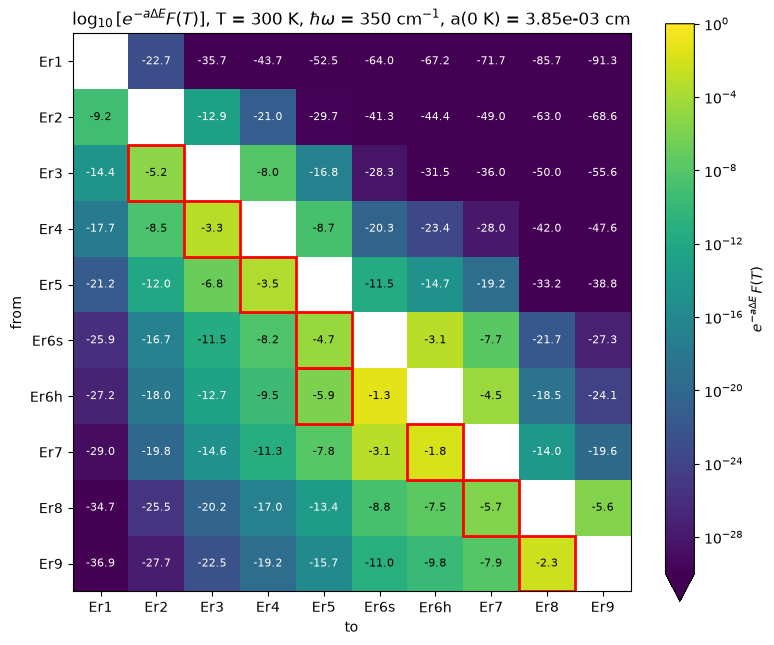

In [4]:
levels = [l for l in er._yield(SingletState)][:10]
E = np.array([(l.energy / hc).to(1 / u.cm).magnitude for l in levels])
existing = {(str(t.source), str(t.target)) for t in er._yield(TemperatureDependentInternalRelaxationRef)}


def gap_law_heatmap(T):
    n = occupation(T)
    V = np.full((len(levels), len(levels)), np.nan)
    for i, Ei in enumerate(E):
        for j, Ej in enumerate(E):
            if i == j:
                continue
            dE = abs(Ei - Ej)
            p = phonon_number(dE)
            F = (1 + n) ** p if Ei > Ej else n**p
            V[i, j] = np.exp(-a * dE) * F
    return V


def plot_heatmap(T, vmin=1e-30):
    V = gap_law_heatmap(T)
    labels = [repr(l) for l in levels]
    fig, ax = plt.subplots(figsize=(9, 7.5))
    norm = LogNorm(vmin=vmin, vmax=1)
    im = ax.imshow(V, norm=norm)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            if np.isfinite(V[i, j]):
                ax.text(j, i, f"{np.log10(V[i, j]):.1f}", ha="center", va="center", fontsize=8,
                        color="k" if norm(V[i, j]) > 0.6 else "w")
            if (labels[i], labels[j]) in existing:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec="r", lw=2))
    fig.colorbar(im, label=r"$e^{-a\Delta E}\,F(T)$", extend="min")
    ax.set_xticks(np.arange(len(levels)), labels)
    ax.set_yticks(np.arange(len(levels)), labels)
    ax.set_ylabel("from")
    ax.set_xlabel("to")
    ax.set_title(
        rf"$\log_{{10}}[e^{{-a\Delta E}} F(T)]$, T = {T} K, "
        rf"$\hbar\omega$ = {phonon_wavenumber:g} cm$^{{-1}}$, a(0 K) = {a:.2e} cm"
    )
    plt.show()
    return V


V = plot_heatmap(T0)

Mismo heatmap a otra temperatura (para ver qué transiciones se prenden al calentar):

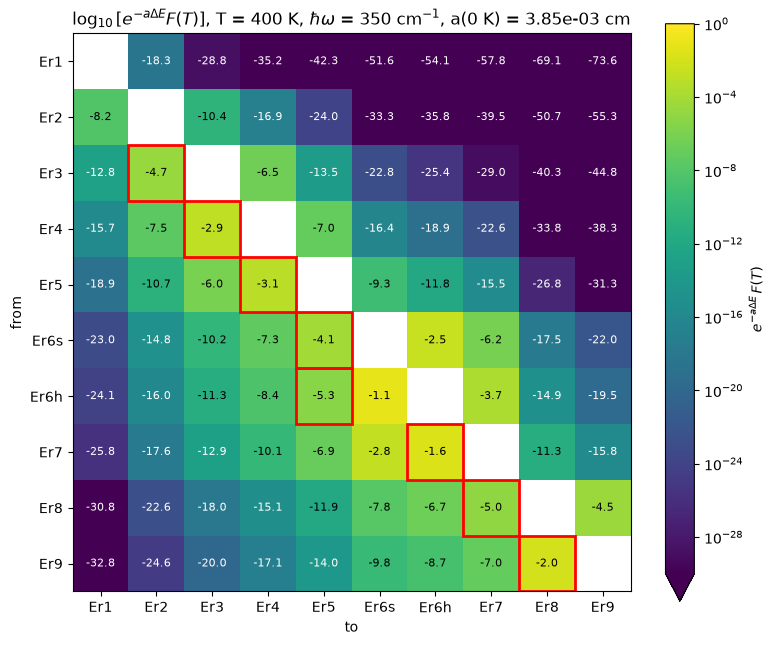

In [5]:
V_hot = plot_heatmap(400)